## Parallel Workflow

In [54]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [64]:
#creating state class
class CricketState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    strike_rate:float
    boundary_per_balls:float
    boundary_percentage:float
    summary:str

In [65]:
#creating strike_rate function
def calculate_strike_rate(state:CricketState):
    strike_rate = (state['runs']/state['balls'])*100
    return {"strike_rate":strike_rate}

In [66]:
#creating boundary per ball function
def boundaryPerBall(state:CricketState):
    bpb = state['balls']/(state['fours']+state['sixes'])
    return {"boundary_per_balls":bpb}

In [67]:
#creating boundary percentage function
def boundary_percentage(state:CricketState):
    boundary_percentage = ((state['fours']*4)+(state['sixes']*6))/state['runs']
    return {"boundary_percentage":boundary_percentage}

In [68]:
#creating summary function
def summary(state:CricketState):
    
    summary = f"""
    
        Strike Rate - {state['strike_rate']} \n
        Balls Per Boundary - {state['boundary_per_balls']} \n
        Boundary Percentage - {state['boundary_percentage']}
    """

    return {"summary":summary}
    

In [69]:
#create graph
graph = StateGraph(CricketState)

#creating nodes

graph.add_node("strike_rate", calculate_strike_rate)
graph.add_node("Boundary_per_ball",boundaryPerBall)
graph.add_node("boundary_percentage",boundary_percentage)
graph.add_node("summary",summary)

#creating edges

graph.add_edge(START,"strike_rate")
graph.add_edge(START,"Boundary_per_ball")
graph.add_edge(START,"boundary_percentage")

graph.add_edge("strike_rate","summary")
graph.add_edge("Boundary_per_ball","summary")
graph.add_edge("boundary_percentage","summary")
graph.add_edge("summary",END)

In [70]:
#compiling
workflow=graph.compile()

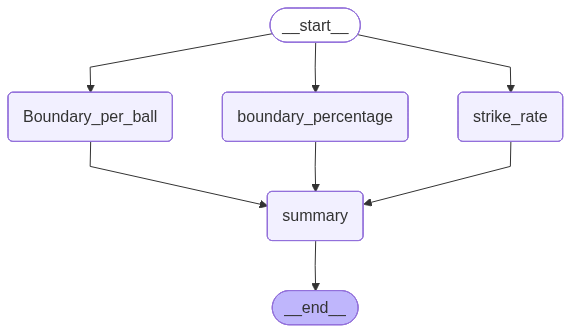

In [71]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [72]:
initial_state = {"runs":100,"balls":42,"fours":10,"sixes":8}
workflow.invoke(initial_state)


{'runs': 100,
 'balls': 42,
 'fours': 10,
 'sixes': 8,
 'strike_rate': 238.0952380952381,
 'boundary_per_balls': 2.3333333333333335,
 'boundary_percentage': 0.88,
 'summary': '\n    \n        Strike Rate - 238.0952380952381 \n\n        Balls Per Boundary - 2.3333333333333335 \n\n        Boundary Percentage - 0.88\n    '}